# Welcome to the first Geometric Deep Learning practical 😀

## Introduction

In this practical we will be exploring *learned* vs *enforced* invariance. Learned invariance is achieved by training general models with an augmented dataset, whereas enforced invariance refers to invariance through choice of architecture.

You will gain hands-on experience by implementing and comparing two distinct neural network models – Multi-layer Perceptron (MLP) and Convolutional Neural Network (CNN). Initially, you'll evaluate the performance of both models in their basic form, without any data augmentation. Following this, you will introduce various data augmentation techniques and observe how these enhancements impact the performance of each model.

We hope you have fun!

Authors:

Charlie Tan charlie.tan@exeter.ox.ac.uk, Ahmed Elhag: ahmed.elhag@st-hildas.ox.ac.uk

### Overview

1. [Geometric Deep Learning Blueprint] - Theoretical motivation
2. [Learned Invariance] - Training general models with data augmentation
3. [Enforcing (Approximate) Invariance] - Employing a 'standard' CNN architecture
4. [Enforcing True Invariance (BONUS!)] - Defining a truly invariant CNN!

### Instructions

- Make a copy of this notebook.
- Make sure the GPU is turned on. Runtime -> Change runtime type -> Hardware accelerator -> GPU
- Fill in your solutions between `### SOLUTION START ###` and `### SOLUTION END ###`. Do not create additional cells.
- Please do not change the signatures of the task functions - this will make it much easier for us to help you.
- Your code should run without errors in Google Colab.

### Imports

To get started, execute the following cell to import the necessary libraries:

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Subset, DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np

In [2]:
print("Using PyTorch version:", torch.__version__)
if torch.cuda.is_available():
    print("Using GPU, device name:", torch.cuda.get_device_name(0))
    device = torch.device("cuda")
else:
    print("No GPU found, using CPU instead.")
    device = torch.device("cpu")

# set seed for pseudo-random number generation
torch.manual_seed(0)

Using PyTorch version: 2.9.0+cu126
Using GPU, device name: NVIDIA L4


### MNIST Dataset

The MNIST (Modified National Institute of Standards and Technology) dataset contains 70,000 images representing handwritten digits. The task is to learn a classifier that correctly identifies each of the digits. MNIST is no longer suitable as a benchmark due to its simplicity, but is ideal for running small experiments as we are today.

We now load the MNIST dataset, passing in a basic transformation to be applied as the samples are drawn. Note that we add padding, which will make the invariance discussion later more convenient.

In [3]:
# transform to convert images to pytorch tensors and normalize them
base_transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,)), transforms.Pad(4, fill=-0.4242)]
)

# download the training and test datasets
train_dataset = datasets.MNIST(
    "./data", train=True, download=True, transform=base_transform
)
test_dataset = datasets.MNIST(
    "./data", train=False, download=False, transform=base_transform
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.11MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]


Inspecting some of the dataset properties:

In [4]:
print(f"There are {len(train_dataset)} images in the training dataset.")
print(f"There are {len(test_dataset)} images in the test dataset.")

print(f"The shape of the images is {train_dataset[0][0].shape}.")
print(f"There are {len(train_dataset.targets.unique())} classes.")

There are 60000 images in the training dataset.
There are 10000 images in the test dataset.
The shape of the images is torch.Size([1, 36, 36]).
There are 10 classes.


Next we visualize a random selection of images from the dataset:

In [5]:
def plot_img(img, ax):
    """
    Plot a single image.

    Args:
        img (torch.Tensor): Image to plot.
        ax (matplotlib.axes.Axes): Axes to plot on.

    """
    img = img.numpy()  # convert to np array
    img = img.transpose(1, 2, 0)  # permute dimensions

    ax.imshow(img, cmap="gray", interpolation=None)  # add to plot
    ax.axis("off")

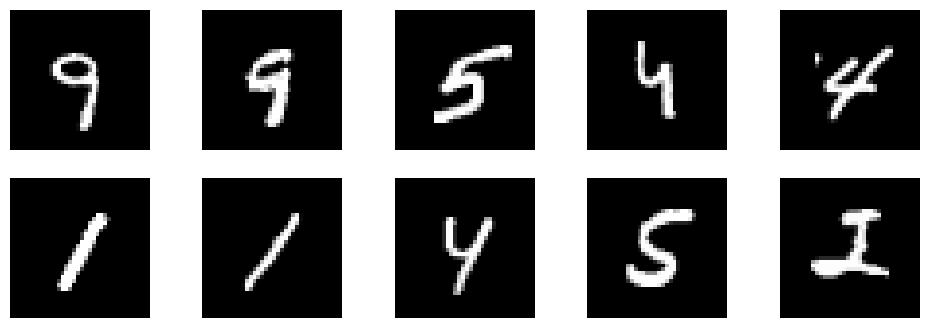

In [6]:
# axes for plotting
fig, axes = plt.subplots(2, 5, figsize=(12, 4))

for i, ax in enumerate(axes.ravel()):
    # select a random image
    img = train_dataset[int(torch.randint(len(train_dataset), (1,)))][0]

    # plot the image
    plot_img(img, ax)

plt.show()

Given the simplicity of the MNIST images, 60,000 training samples is sufficient for a multi-layer perceptron (MLP) to achieve ~99% testing accuracy without data augmentation.

To create a more challenging task on which we may evaluate the different forms of invariance, we constrain ourselves to a subset of size 250 - wherein we have 25 samples per class. To speed up experiments we also reduce the test dataset to only 1000 samples, giving an accurate but fast approximation of the 'true' test accuracy.

The following function is used to generate a balanced subset of given sizes.


In [7]:
def class_balanced_subset(dataset, subset_size):
    """
    Create a class-balanced subset of a given dataset.

    Args:
        dataset (torch.utils.data.Dataset): The original dataset.
        subset_size (int): The desired size of the subset.

    Returns:
        torch.utils.data.Subset: The class-balanced subset.

    """

    targets = dataset.targets.unique()
    num_classes = len(targets)

    assert not subset_size % num_classes
    samples_per_class = subset_size // num_classes

    subset_indices = []

    for target in targets:
        target_indices = torch.nonzero(dataset.targets == target)
        subset_indices.append(target_indices[:samples_per_class].flatten())

    subset = Subset(dataset, torch.cat(subset_indices))

    return subset


NUM_TRAIN = 250
NUM_TEST = 1000

train_subset = class_balanced_subset(train_dataset, NUM_TRAIN)
test_subset = class_balanced_subset(test_dataset, NUM_TEST)

We lastly initialize dataloaders for the train and test data, each drawing batches of size `batch_size_subset` from their respective datasets.

In [8]:
batch_size_train = 16
batch_size_test = len(test_subset) // 10  # for easy accurate accuracy calculation

train_loader = DataLoader(train_subset, batch_size_train, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size_test, shuffle=False, num_workers=2)

## Section 1: The Geometric Deep Learning Blueprint

The Geometric Deep Learning (GDL) Blueprint gives a recipe for building powerful Deep Learning models from geometric principles. The blueprint interleaves equivariant linear layers with point-wise non-linearity, in some cases pooling layers are additionally included. The last component of the blueprint is an invariant layer.

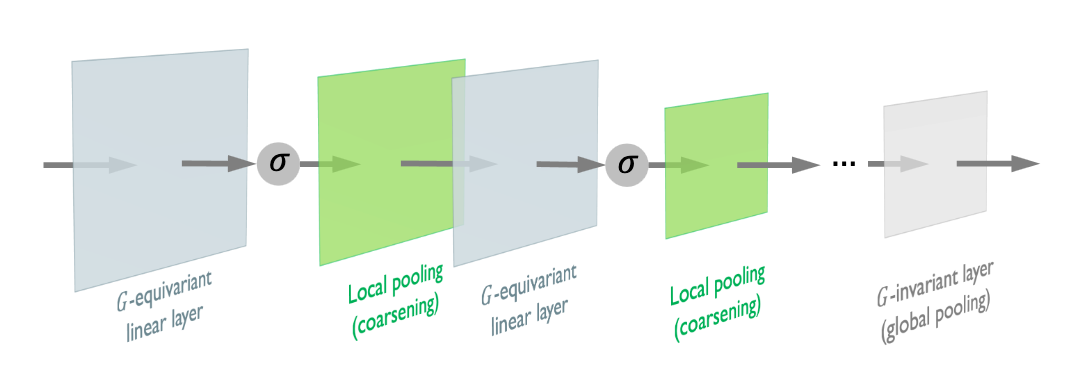

### Task 1.1 GDL blueprint
Write a paragraph commenting on the GDL Blueprint. Consider the following questions:

*   What is the purpose of each component?
*   Why do we use the invariant layer only at the end? - What would happen if the invariant layer was placed at the start?
*   Why may we need multiple equivariant layers - possibly interleaved with pooling layers?

Equivariants layer + pooling allow to propagate the information downstream without loss to avoid relying on locality. The sigmoid function introduces non-linearity. Without it, the equivariant layers could be collapsed into one layer, largely reducing expressivity.
Lastly, we have to put the invariant layer at the end to avoid a loss of information. If it were at the start, we wouldn't be able to distinguish between geometric projections such as rotations which would be very useful.

### Task 1.2 Symmetries in images

Images are great examples to think about symmetries. While there are many different kinds of symmetries that can be applied to images, for the sake of this practical we will mainly focus on translations. Given a image represented as an n by n grid, a translation can be described by two numbers dx and dy, which represent respectively how much the first and second coordinates translate. We now ask you to use the [torch.roll](https://docs.pytorch.org/docs/stable/generated/torch.roll.html) function in order to implement translations, which we visualize below. Note that since images have only finitely many pixels in each dimensions, we need to assume some form of boundary condition, roll assumes periodic boundary conditions.

In [9]:
def circular_shift(x, dx: int, dy: int):
    """
    Circularly shifting a batch with dimensions BxCxHxW by (dx, dy) pixels.
    """
    ### SOLUTION STARTS ###
    translated_x = torch.roll(x, shifts=(dx, dy), dims=(1,0))
    ### SOLUTION ENDS ###

    return translated_x


We now visualize the results

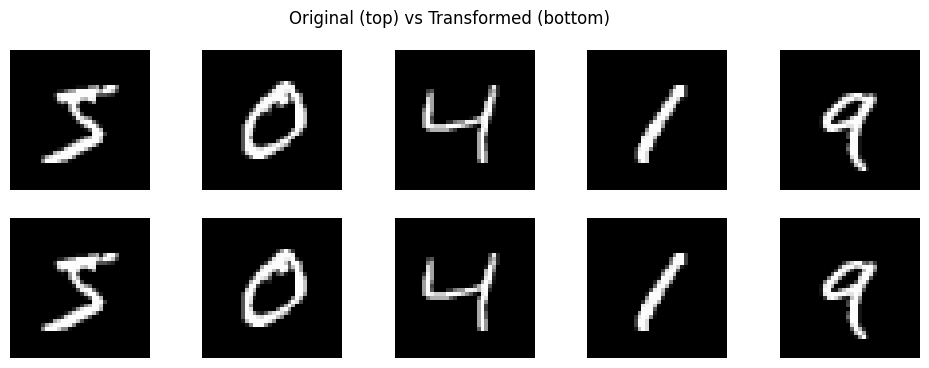

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(12, 4))

max_translation = 7  # small value to avoid translating through the boundary

for i in range(5):
    img = train_dataset[i][0]       # original
    plot_img(img, axes[0, i])        # first row

    trans_img = circular_shift(img.unsqueeze(0), dx=(3*i)%max_translation, dy=(2*i)%max_translation).squeeze(0)
    plot_img(trans_img, axes[1, i])      # second row
fig.suptitle("Original (top) vs Transformed (bottom)")

plt.show()

Can you think of other symmetries potentially arising in images?


There can also be rotational symmetry (e.g. taking a picture of a wheel), but this does not apply to every image (e.g. humans walking on ceilings).

There can also be reflective symmetry that can apply to symmetrical objects.

## Section 2: Learned Invariance

When performing image classification we are not concerned with an object's location within the image. We are therefore interested in learning a *translation-invariant* function - one that will output the same class irrespective of an object's spatial position.

One approach to solving this is to employ a *general* function class, that does not encode any geometric prior, and augment our dataset with random translations. A multi-layer perceptron composes linear transformations with non-linear activation functions, resulting in a general function class.

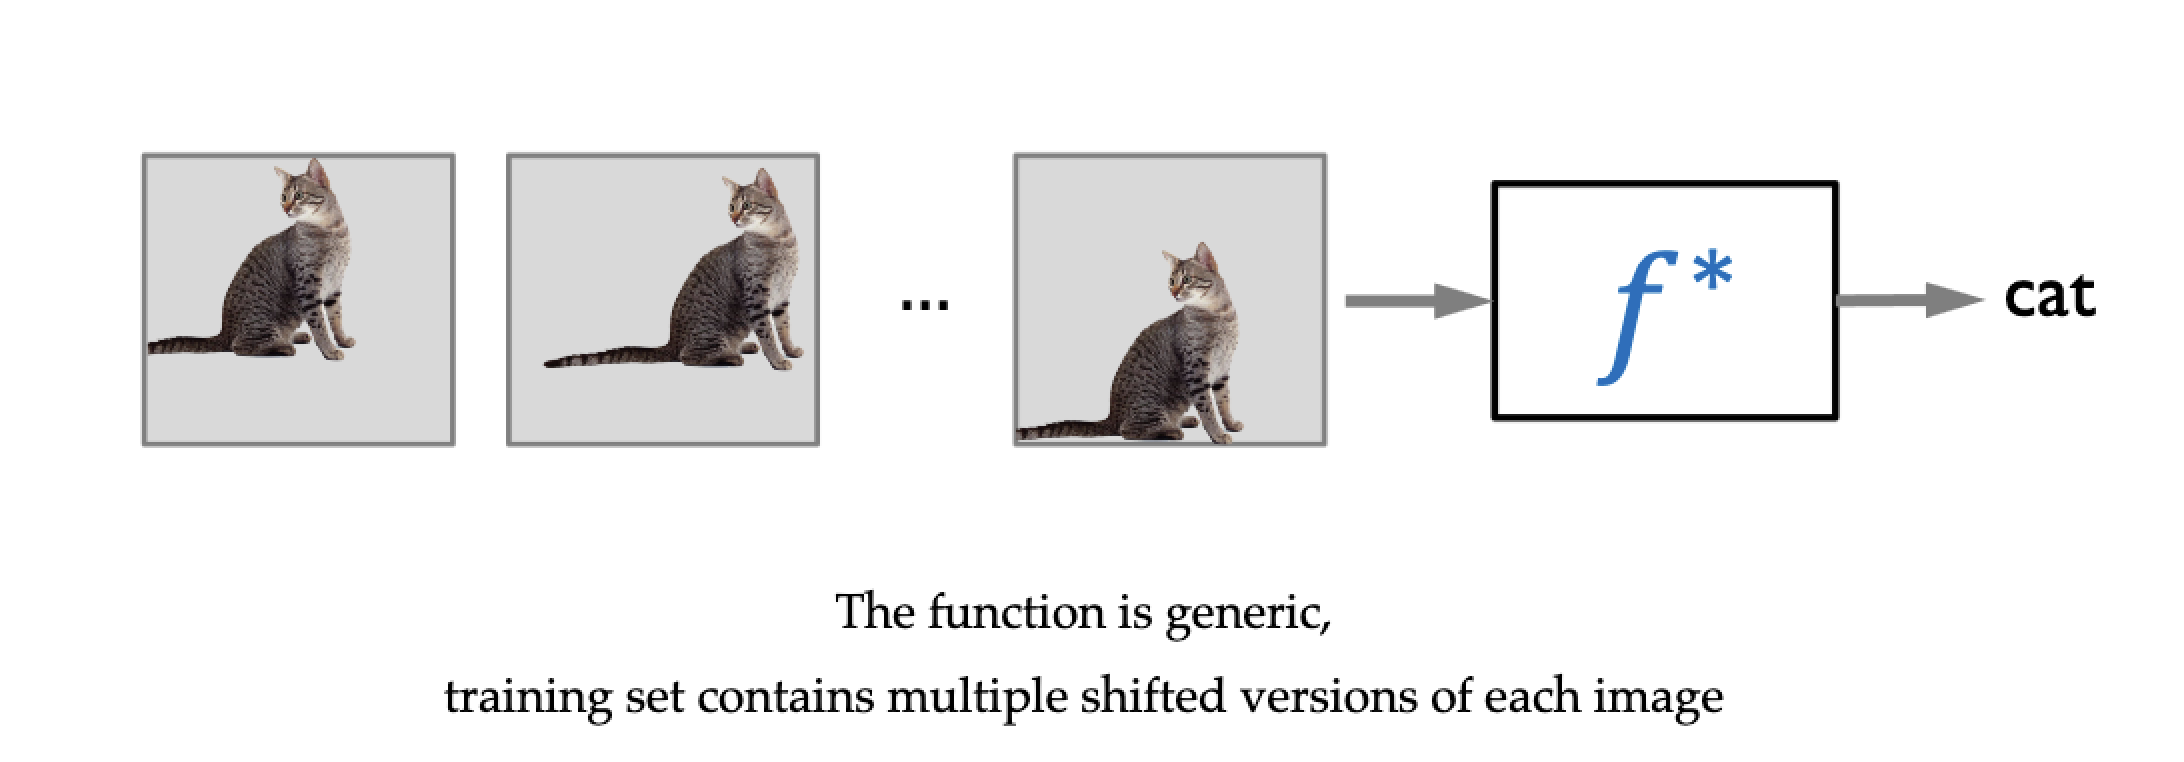

### Task 2.1 MLP Implementation

In this task, you will implement a multi-layer perceptron (MLP) in PyTorch.

The MLP model is a series of linear transformations composed with ReLU activation. The final linear layer maps to the class logits and is not followed by an activation.

The model architecture is defined by the arguments of `__init__`, where `sz_hids` defines the dimensionality of any hidden layer(s). Do not use any batch / layer normalization.

In [63]:
class MLP(nn.Module):
    """
    Multi-Layer Perceptron (MLP) model.
    """

    def __init__(self, input_shape=(1, 36, 36), sz_hids=[1024], num_classes=10):
        """
        Initialize the MLP model.

        Args:
            input_shape (tuple): Input shape, default is (1, 28, 28)
            sz_hids (list): List of hidden layer sizes, default is [1024].
            num_classes (int): Number of output classes, default is 10.

        There should be len(sz_hids) hidden layers, hence (len(sz_hids) + 1) linear layers.

        """

        ### SOLUTION START ###
        super().__init__()
        self.input_shape = input_shape
        self.sz_hids = sz_hids
        self.num_classes = num_classes

        input_dim = np.prod(input_shape)
        self.hidden_layers = nn.ModuleList()
        prev_dim = input_dim
        for dim in sz_hids:
            self.hidden_layers.append(nn.Linear(prev_dim, dim))
            prev_dim = dim
        self.output_layer = nn.Linear(prev_dim, num_classes)
        ### SOLUTION END ###

    def forward(self, x):
        """
        Forward pass of the MLP model.

        Args:
            x (torch.Tensor): Input tensor.

        Returns:
            torch.Tensor: Output tensor.

        """

        ### SOLUTION STARTS HERE ###
        x = x.view(x.size(0), -1)
        for layer in self.hidden_layers:
            x = F.relu(layer(x))
        x = self.output_layer(x)
        ### SOLUTION ENDS HERE ###

        return x

We now initialize your model and process a batch of images, asserting that we are outputting a tensor of the correct shape.

In [64]:
model = MLP().to(device)
img = next(iter(test_loader))[0].to(device)
output = model(img)
assert output.shape == (batch_size_test, 10)

We've provided the following functions for training and evaluating our model.

In [17]:
def get_acc(outputs, labels):
    """
    Calculate the accuracy of the model predictions.

    Args:
        outputs (torch.Tensor): Model outputs.
        labels (torch.Tensor): Ground truth labels.

    Returns:
        torch.Tensor: Accuracy of the model predictions.

    """
    return (outputs.argmax(dim=1) == labels).sum().float() / outputs.shape[0]

In [18]:
def train_epoch(model, dataloader, loss_fn, opt):
    """
    Perform a single training epoch.

    Args:
        model (nn.Module): The model to train.
        dataloader (torch.utils.DataLoader): The dataloader containing the training data.
        loss_fn (Callable): The loss function to calculate the loss.
        opt (torch.optim.Optimizer): The optimizer to update the model parameters.

    Returns:
        float: Mean loss value.
        float: Mean accuracy value.

    """

    model.train()

    losses = []
    accs = []

    for data, target in dataloader:
        opt.zero_grad()  # zero gradients in the optimizer
        data, target = data.to(device), target.to(device)

        output = model(data)  # forward pass through the model
        loss = loss_fn(output, target)  # calculate the loss

        loss.backward()  # backpropagate the loss
        opt.step()  # update the model parameters

        losses.append(loss.item())
        accs.append(get_acc(output, target).item())

    mean_loss = np.mean(losses)
    mean_acc = np.mean(accs)

    return mean_loss, mean_acc

In [19]:
# decorator to disable gradient calculation during evaluation
@torch.no_grad()
def evaluate(model, dataloader, loss_fn):
    """
    Evaluate the model on the given dataloader.
    Args:

        model (nn.Module): The model to evaluate.
        dataloader (torch.utils.data.DataLoader): The dataloader containing the evaluation data.
        loss_fn (Callable): The loss function to calculate the loss.

    Returns:
        float: Mean loss value.
        float: Mean accuracy value.

    """

    model.eval()

    losses = []
    accs = []

    for data, target in dataloader:
        data, target = data.to(device), target.to(device)

        output = model(data)  # forward pass through the model
        loss = loss_fn(output, target)  # calculate the loss

        losses.append(loss.item())
        accs.append(get_acc(output, target).item())

    mean_loss = np.mean(losses)
    mean_acc = np.mean(accs)

    return mean_loss, mean_acc

In [20]:
def training_run(model, train_loader, test_loader, num_epochs=40, patience=10):
    """
    Perform a full training run.

    Args:
        model (nn.Module): The model to train.
        train_loader (torch.utils.data.DataLoader): The dataloader containing the training data.
        test_loader (torch.utils.data.DataLoader): The dataloader containing the test data.
        num_epochs (int): The number of training epochs.
        patience (int): The number of epochs to wait for improvement in test accuracy before early stopping.
    """

    loss_fn = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=0.001)

    best_test_acc = -1
    patience_counter = 0

    for i in range(num_epochs):
        # train the model for one epoch
        train_loss, train_acc = train_epoch(model, train_loader, loss_fn, opt)

        # evaluate the model on the test data
        test_loss, test_acc = evaluate(model, test_loader, loss_fn)

        # check if the current test accuracy is better than the best test accuracy so far
        if test_acc > best_test_acc:
            best_test_acc = test_acc

            # add a message indicating a new best test accuracy
            msg = "- new best!"

            # reset the patience counter
            patience_counter = 0
        else:
            # empty message if there is no improvement in test accuracy
            msg = ""

            # increment the patience counter
            patience_counter += 1

        # print the training and test metrics for the current epoch
        print(
            f"Epoch {i+1:02d}: train loss {train_loss:.4f} train acc {train_acc:.4f} test loss {test_loss:.4f} test acc {test_acc:.4f} {msg}"
        )

        if patience_counter == patience:
            print(f"No progress after {patience} epochs - stopping early.\n")
            break

The following function is used counts the number of learnable parameters in our model:

In [21]:
def count_parameters(model):
    """
    Count the number of trainable parameters in a PyTorch model.

    Args:
        model (nn.Module): The PyTorch model.

    Returns:
        int: The number of trainable parameters.

    """
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Now train the MLP you have implemented on the training data - you should reach around 82% test accuracy.

In [70]:
model = MLP().to(device)

print(f"Model contains {count_parameters(model)} trainable parameters\n")


Model contains 1338378 trainable parameters



In [71]:
training_run(model, train_loader, test_loader)

Epoch 01: train loss 1.5438 train acc 0.4703 test loss 0.9319 test acc 0.7227 - new best!
Epoch 02: train loss 0.4631 train acc 0.8414 test loss 0.7803 test acc 0.7446 - new best!
Epoch 03: train loss 0.2413 train acc 0.9195 test loss 0.6921 test acc 0.7812 - new best!
Epoch 04: train loss 0.1359 train acc 0.9570 test loss 0.6857 test acc 0.7852 - new best!
Epoch 05: train loss 0.0789 train acc 0.9844 test loss 0.7271 test acc 0.7951 - new best!
Epoch 06: train loss 0.0628 train acc 0.9922 test loss 0.6892 test acc 0.7962 - new best!
Epoch 07: train loss 0.0192 train acc 1.0000 test loss 0.6633 test acc 0.8150 - new best!
Epoch 08: train loss 0.0141 train acc 1.0000 test loss 0.6721 test acc 0.8111 
Epoch 09: train loss 0.0102 train acc 1.0000 test loss 0.6701 test acc 0.8118 
Epoch 10: train loss 0.0081 train acc 1.0000 test loss 0.6728 test acc 0.8156 - new best!
Epoch 11: train loss 0.0068 train acc 1.0000 test loss 0.6836 test acc 0.8144 
Epoch 12: train loss 0.0061 train acc 1.000

### Task 2.2 Quantified Learned Invariance

In this task, you will implement a method to **quantify** (measure) how translation-invariant a model is, and use it to analyze the results of each architecture (**MLP**, **CNN**) trained **with and without data augmentation**.


You will implement two metrics:

- **`pred_agree` (↑):** fraction of random shifts where the **predicted class (argmax)** stays the same:
  $$
  \mathbb{E}_{x \sim \mathcal{D},\; T \sim \mathcal{G}}
  \big[\mathbf{1}\{\arg\max z(x) = \arg\max z(T(x))\}\big]
  $$
  *(higher means more invariant function)*

- **`logit_mse` (↓):** average **mean-squared change of normalized logits** under shifts:
  $$
  \mathbb{E}_{x \sim \mathcal{D},\; T \sim \mathcal{G}}
  \left[\frac{1}{K}\left\|\frac{z(x)}{\|z(x)\|_2}-\frac{z(T(x))}{\|z(T(x))\|_2}\right\|_2^2\right]
  $$
  *(lower means more invariant function)*

where:


- $T \in \mathcal{G}$ is a random translation applied to the image $x$.  
- $z(x)\in\mathbb{R}^K$ are the model **logits** (outputs of the model before softmax) for $K$ classes.
- $\arg\max$ is the index of the predicted class.
- $\mathbf{1}\{\cdot\}$ is 1 if the statement is true, else 0.
- $\mathbb{E}[\cdot]$ is the average over multiple samples with random shifts.

We will compute these two metrics on our test dataset and compare the results of training each model with/ without data augmentation.



Hint: Use the circular_shift function that you implemented in task 1.2 to get a translated version of your input images.

In [14]:
# --- Invariance metrics ---

@torch.no_grad()
def invariance_metrics(
    model,
    dataloader,
    max_shift: int = 3,
    num_shifts: int = 20,
    num_batches: int | None = None,
):
    """
    Compute invariance metrics under random circular shifts.

    Args:
        model (nn.Module): The PyTorch model.
        dataloader (torch.utils.data.DataLoader): The dataloader containing the test data.
        max_shift (int): Maximum shift size (pixels). Shifts are sampled uniformly from {-max_shift, +max_shift}
        num_shifts (int): The number of random shifts per batch.
        num_batches (int): The number of batches we want to calculate invariance metrics for.

    Returns:
        float in [0,1]: fraction of shifts where the predicted class (argmax) stays the same.
        float ≥ 0: Average per-class mean squared error between logits before/after shifting.

    """

    model.eval()

    # You will implement:
    # 1) pred_agree: fraction of shifts that preserve argmax class
    # 2) logit_mse: mean squared error of model logits (per class)

    total_agree = 0.0
    total_logit_mse = 0.0
    total_examples = 0

    for b, (x, y) in enumerate(dataloader):
        if num_batches is not None and b >= num_batches:
            break

        x = x.to(device)

        logits = model(x)
        probs = F.softmax(logits, dim=-1)

        B, C = logits.shape

        for _ in range(num_shifts):

            ### SOLUTION STARTS ###
            dx, dy = np.random.randint(-max_shift, max_shift + 1), np.random.randint(-max_shift, max_shift + 1)
            x_shift = circular_shift(x, dx, dy)
            logits_shift = model(x_shift)
            probs_shift = F.softmax(logits_shift, dim=-1)

            for i in range(B):
                if torch.argmax(probs[i], dim=-1) == torch.argmax(probs_shift[i], dim=-1):
                    total_agree += 1

            zx_normalized = F.normalize(logits, p=2.0, dim=-1)
            zTx_normalized = F.normalize(logits_shift, p=2.0, dim=-1)
            total_logit_mse += ((zx_normalized - zTx_normalized)**2).mean(dim=-1).sum()
            ### SOLUTION END ###



        total_examples += B

    return {
        "pred_agree": total_agree / (total_examples * num_shifts),
        "logit_mse": total_logit_mse / (total_examples * num_shifts),
    }


Calculate the invariance metrics for the MLP model

In [73]:
invariance_metrics(model, test_loader, num_batches=10)

{'pred_agree': 0.21415, 'logit_mse': tensor(0.1350, device='cuda:0')}

Now with our MLP defined and a baseline accuracy with which to compare, we now proceed to train using translations as data augmentation.

To implement the dataloader we use RandomCrop transform that performs translation augmentation by first adding padding on each sides of the images and then taking a random crop back to the original size.


In [74]:
# the new transform is the composition of our random translation and the base transform
translate_transform = transforms.Compose(
    [base_transform, transforms.RandomCrop((36, 36), 4, fill=-0.4242)] # we use the RandomCrop to help us implement small random translations
)

# new train_subset with the augmented transform
train_dataset_translate = datasets.MNIST(
    "./data", train=True, download=True, transform=translate_transform
)
train_subset_translate = class_balanced_subset(train_dataset_translate, NUM_TRAIN)

# new train_loader
train_loader_translate = DataLoader(
    train_subset_translate, batch_size_train, shuffle=True, num_workers=2
)

### Task 2.3 MLP on augmented dataset

Train your MLP on this augmented dataset

In [75]:
model = MLP().to(device)
print(f"Model contains {count_parameters(model)} trainable parameters\n")
print(f"Invariance metrics of the model pre-training: ", invariance_metrics(model, test_loader, num_batches=10), "\n")
training_run(model, train_loader_translate, test_loader)

Model contains 1338378 trainable parameters

Invariance metrics of the model pre-training:  {'pred_agree': 0.3131, 'logit_mse': tensor(0.1084, device='cuda:0')} 

Epoch 01: train loss 2.3053 train acc 0.1875 test loss 2.0806 test acc 0.2614 - new best!
Epoch 02: train loss 1.9456 train acc 0.2828 test loss 1.6501 test acc 0.4490 - new best!
Epoch 03: train loss 1.7482 train acc 0.3289 test loss 1.5771 test acc 0.4671 - new best!
Epoch 04: train loss 1.6466 train acc 0.4313 test loss 1.4571 test acc 0.5574 - new best!
Epoch 05: train loss 1.4760 train acc 0.4672 test loss 1.3216 test acc 0.5759 - new best!
Epoch 06: train loss 1.2888 train acc 0.5688 test loss 1.2763 test acc 0.5765 - new best!
Epoch 07: train loss 1.1754 train acc 0.6344 test loss 1.2641 test acc 0.5901 - new best!
Epoch 08: train loss 1.1871 train acc 0.6188 test loss 1.2160 test acc 0.5909 - new best!
Epoch 09: train loss 1.0905 train acc 0.6750 test loss 1.1396 test acc 0.6097 - new best!
Epoch 10: train loss 1.0363

Calculate the invariance metrics for the MLP model trained with data augmentation

In [76]:
print(f"Invariance metrics of the model post-training: ", invariance_metrics(model, test_loader, num_batches=10))

Invariance metrics of the model post-training:  {'pred_agree': 0.23655, 'logit_mse': tensor(0.1106, device='cuda:0')}


Discuss the results in relation to the previous experiment (accuracy and invariance metrics).

We see a slight improvement in accuracy that is due to the essentially "new" data created from the shifts. We also see a slight improvement in pred_agree due to the fact that shifts are now integrated within the dataset.

## Section 3: Enforcing (Approximate) Invariance

We have just seen that applying data augmentation when training a general function class enables us to learn a better classifier. The GDL Blueprint provides another solution, wherein our learnable function $f$ is *a priori* assumed to be shift-invariant.


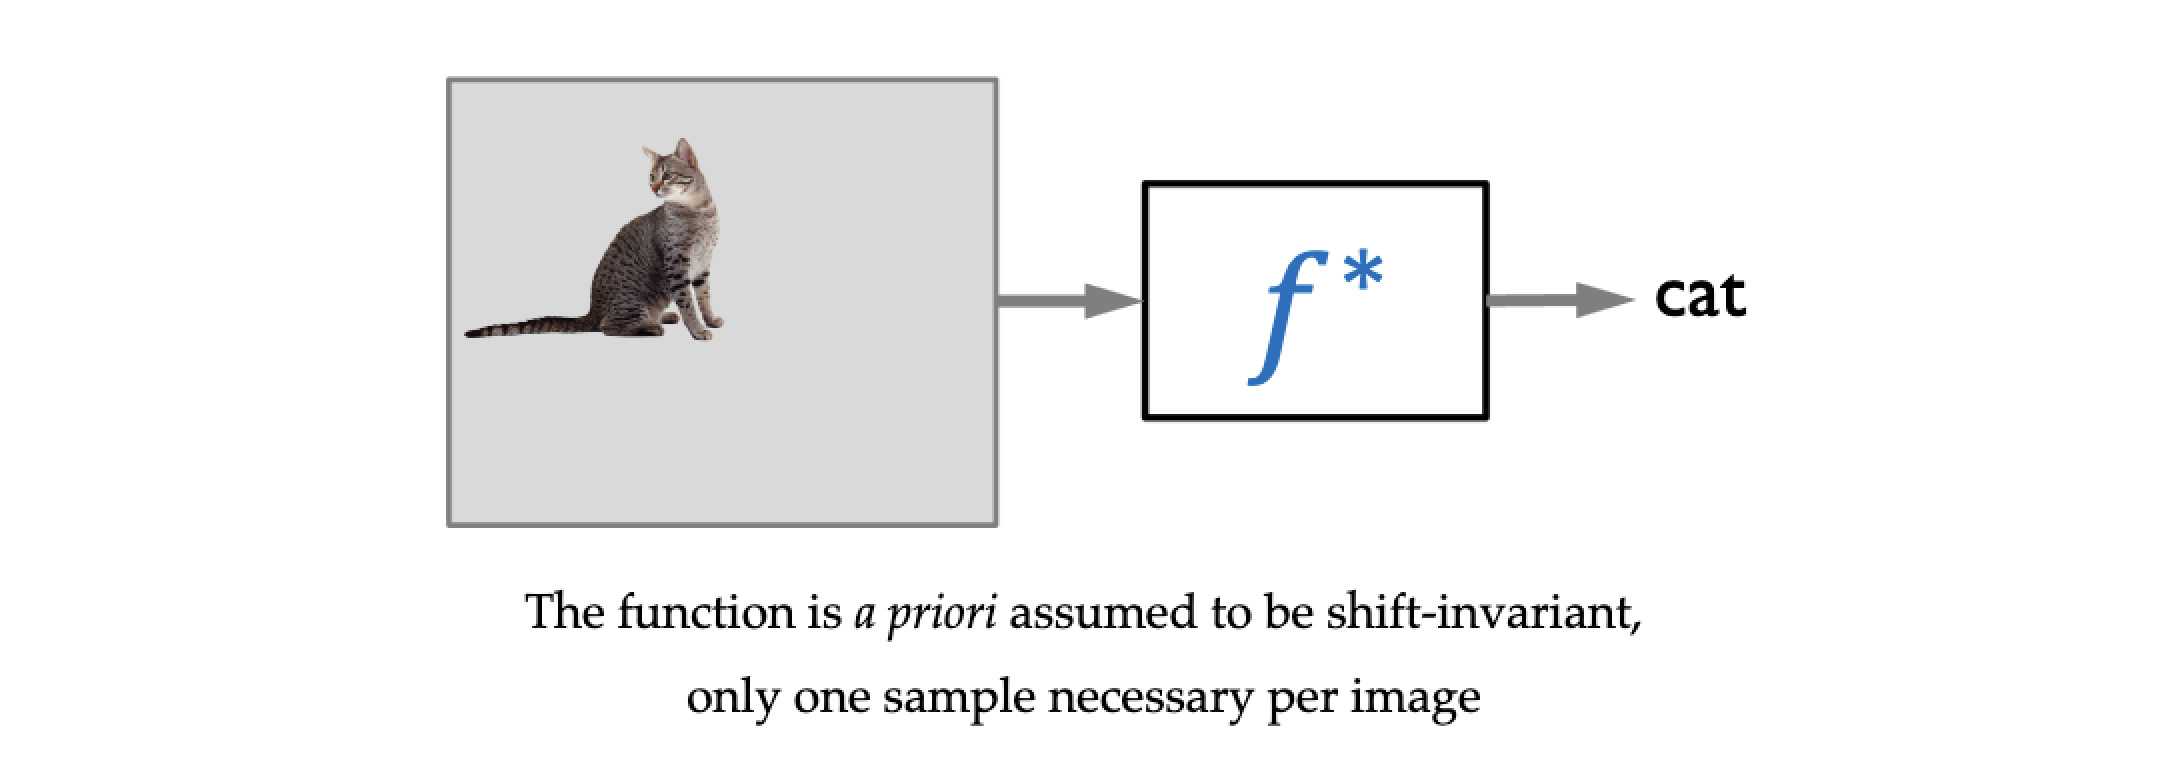

The discrete convolution is equivariant to (circular) shifts, and is the building block of a convolutional neural network (CNN). The shift equivariance of the convolution operation will be covered in the week 3 lecture, and is also discussed in Section 4.2 of [Geometric Deep Learning Grids, Groups, Graphs, Geodesics and Gauges](https://arxiv.org/pdf/2104.13478.pdf).

Discrete convolutions are equivalent to left multiplication by a *circulant matrix*. Given a vector $\mathbf{\theta} = (\theta_0,...,\theta_{n-1})$, the circulant matrix $\mathbf{C}(\mathbf{\theta})$ is defined as:

$$
C(\mathbf{\theta}) =
\begin{bmatrix}
    \theta_{0} & \theta_{1} & & & \theta_{n-1} \\
    \theta_{n-1} & \theta_{0} & \theta_{1} & &\\
    & \ddots & \ddots & \ddots &\\
    &  & \theta_{n-1} & \theta_{0} & \theta_{1}\\
    \theta_{1} &  & & \theta_{n-1} & \theta_{0}\\
\end{bmatrix}
$$

Left multiplication by the circulant matrix $\mathbf{C}(\mathbf{\theta})$ is equivalent to performing (circular) discrete convolution by the vector $\mathbf{\theta}$.

$$\mathbf{C}(\mathbf{\theta})\mathbf{z} = \mathbf{z}  \star \mathbf{\theta} $$

### Task 3.1 Circulant matrices

Where $\mathbf{\theta} = (0,1,0,...,0)$, the circulant matrix is known as the (right) shift matrix $\mathbf{S} = \mathbf{C}(\mathbf{\theta})$

Prove that a matrix $\mathbf{X}$ is circulant if it commutes with $\mathbf{S}$.

Hint: expand the matrix multiplication $\mathbf{S} \mathbf{X} = \mathbf{X} \mathbf{S}$ element-wise.

$$\mathbf{SX} = \mathbf{XS}$$

$$ \Leftrightarrow
 \begin{bmatrix}
    0 & 1 & & & 0 \\
    0 & 0 & 1 & &\\
    & \ddots & \ddots & \ddots &\\
    &  & 0 & 0 & 1\\
    1 &  & & 0 & 0\\
\end{bmatrix}
 \begin{bmatrix}
    x_{0,0} & x_{0,1} & & & x_{0,n-1} \\
    x_{1, 0} & x_{1,1} & x_{1,2} & &\\
    & \ddots & \ddots & \ddots &\\
    &  & x_{n-2, n-3} & x_{n-2,n-2} & x_{n-2,n-1}\\
    x_{n-1, 0} &  & & x_{n-1,n-2} & x_{n-1,n-1}\\
\end{bmatrix}
=
 \begin{bmatrix}
    x_{0,0} & x_{0,1} & & & x_{0,n-1} \\
    x_{1, 0} & x_{1,1} & x_{1,2} & &\\
    & \ddots & \ddots & \ddots &\\
    &  & x_{n-2, n-3} & x_{n-2,n-2} & x_{n-2,n-1}\\
    x_{n-1, 0} &  & & x_{n-1,n-2} & x_{n-1,n-1}\\
\end{bmatrix}
\begin{bmatrix}
    0 & 1 & & & 0 \\
    0 & 0 & 1 & &\\
    & \ddots & \ddots & \ddots &\\
    &  & 0 & 0 & 1\\
    1 &  & & 0 & 0\\
\end{bmatrix}
$$


$$ \Leftrightarrow
 \begin{bmatrix}
    x_{1,0} & x_{1,1} & & & x_{1,n-1} \\
    x_{2, 0} & x_{2,1} & x_{2,2} & &\\
    & \ddots & \ddots & \ddots &\\
    &  & x_{n-1, n-3} & x_{n-1,n-2} & x_{n-1,n-1}\\
    x_{0, 0} &  & & x_{0,n-2} & x_{0,n-1}\\
\end{bmatrix}
=
 \begin{bmatrix}
    x_{0,n-1} & x_{0,0} & & & x_{0,n-2} \\
    x_{1, n-1} & x_{1,0} & x_{1,1} & &\\
    & \ddots & \ddots & \ddots &\\
    &  & x_{n-2, n-4} & x_{n-2,n-3} & x_{n-2,n-2}\\
    x_{n-1,n-1} &  & & x_{n-1,n-3} & x_{n-1,n-2}\\
\end{bmatrix}
$$

Then, if we look at each element-wise equality, we satisfy the conditions of equality for $C(\theta)$.

### Task 3.2 CNN implementation

Now after benchmarking the MLP, we will implement a Convolution Neural Network (CNN) model with the following architecture:

Convolution\
ReLU\
MaxPool (subsample by factor of 2)\
Convolution\
ReLU\
MaxPool (subsample by factor of 2)\
Convolution\
ReLU\
Flatten\
Linear

The argument `feature_dims` defines the feature map dimension of each convolutional layer. Do not use any batch / layer normalization.

In [77]:
class CNN(nn.Module):
    """
    Convolutional Neural Network (CNN) model.
    """

    def __init__(
        self, input_shape=(1, 36, 36), feature_dims=[64, 64, 32], num_classes=10
    ):
        """
        Initialize the CNN model.

        Args:
            input_shape (tuple): The shape of the input tensor, default is (1, 28, 28).
            feature_dims (list): List of feature dimensions, default is [64, 64, 32].
            num_classes (int): Number of output classes, default is 10.

        There should be len(feature_dims) convolutional layers and a single linear layer.

        """

        super().__init__()

        ### SOLUTION START ###
        self.conv1 = nn.Conv2d(input_shape[0], feature_dims[0], 3, padding=1)
        self.conv2 = nn.Conv2d(feature_dims[0], feature_dims[1], 3, padding=1)
        self.conv3 = nn.Conv2d(feature_dims[1], feature_dims[2], 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(feature_dims[2] * input_shape[1]//4 * input_shape[2]//4, num_classes)
        ### SOLUTION END ###

    def forward(self, x):
        """
        Forward pass of the CNN model.

        Args:
            x (torch.Tensor): Input tensor.

        Returns:
            torch.Tensor: Output tensor.

        """

        ### SOLUTION START ###
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = F.relu(self.conv3(x))
        x = torch.flatten(x, 1)
        x = self.fc(x)
        ### SOLUTION END ###

        return x

We now initialize your model and process a batch of images, asserting that we are outputting the a tensor of the correct shape.

In [78]:
model = CNN().to(device)
img = next(iter(test_loader))[0].to(device)
output = model(img)
assert output.shape == (batch_size_test, 10)

### Task 3.3 CNN training

Train the CNN on the original (no augmentation) dataset - you should achieve around 87% test accuracy.

In [79]:
model = CNN().to(device)
print(f"Model contains {count_parameters(model)} trainable parameters\n")
print(f"Invariance metrics of the model pre-training: ", invariance_metrics(model, test_loader, num_batches=10), "\n")
training_run(model, train_loader, test_loader)

Model contains 81962 trainable parameters

Invariance metrics of the model pre-training:  {'pred_agree': 0.45155, 'logit_mse': tensor(0.0257, device='cuda:0')} 

Epoch 01: train loss 2.0967 train acc 0.3367 test loss 1.4596 test acc 0.6433 - new best!
Epoch 02: train loss 0.9122 train acc 0.7461 test loss 0.9624 test acc 0.6877 - new best!
Epoch 03: train loss 0.5347 train acc 0.8258 test loss 0.9046 test acc 0.6892 - new best!
Epoch 04: train loss 0.3430 train acc 0.8781 test loss 0.6559 test acc 0.8059 - new best!
Epoch 05: train loss 0.2302 train acc 0.9234 test loss 0.6062 test acc 0.8276 - new best!
Epoch 06: train loss 0.1159 train acc 0.9727 test loss 0.6100 test acc 0.8316 - new best!
Epoch 07: train loss 0.0420 train acc 0.9961 test loss 0.7246 test acc 0.8270 
Epoch 08: train loss 0.0211 train acc 1.0000 test loss 0.7814 test acc 0.8274 
Epoch 09: train loss 0.0108 train acc 1.0000 test loss 0.7456 test acc 0.8428 - new best!
Epoch 10: train loss 0.0060 train acc 1.0000 test 

Calculate the invariance metrics for the CNN model

In [80]:
print(f"Invariance metrics of the model post-training: ", invariance_metrics(model, test_loader, num_batches=10))

Invariance metrics of the model post-training:  {'pred_agree': 0.2006, 'logit_mse': tensor(0.0497, device='cuda:0')}


Discuss this result in relation to the previous experiments. Why does this CNN architecture fails to achieve exact invariance to translation?

Max pooling introduces slight locality issues. Three levels of depth also imply that the receptive field is not the global picture but still has some level of locality.

### Task 3.4 CNN and exact invariance


Run the CNN on the translation-augmented dataset as defined earlier. Why does this further increase the performance? And how does it affect the invariance metrics?

In [81]:
model = CNN().to(device)
print(f"Model contains {count_parameters(model)} trainable parameters\n")
training_run(model, train_loader_translate, test_loader)

Model contains 81962 trainable parameters

Epoch 01: train loss 2.2967 train acc 0.1195 test loss 2.1904 test acc 0.1831 - new best!
Epoch 02: train loss 2.1052 train acc 0.2820 test loss 1.5683 test acc 0.5526 - new best!
Epoch 03: train loss 1.6590 train acc 0.4609 test loss 1.3410 test acc 0.4999 
Epoch 04: train loss 1.3159 train acc 0.5555 test loss 0.8637 test acc 0.7267 - new best!
Epoch 05: train loss 0.9803 train acc 0.6984 test loss 0.6377 test acc 0.7978 - new best!
Epoch 06: train loss 0.8128 train acc 0.7453 test loss 0.5432 test acc 0.8370 - new best!
Epoch 07: train loss 0.5861 train acc 0.8320 test loss 0.4901 test acc 0.8349 
Epoch 08: train loss 0.4612 train acc 0.8516 test loss 0.4118 test acc 0.8689 - new best!
Epoch 09: train loss 0.5110 train acc 0.8258 test loss 0.4107 test acc 0.8573 
Epoch 10: train loss 0.4748 train acc 0.8375 test loss 0.3560 test acc 0.8893 - new best!
Epoch 11: train loss 0.4726 train acc 0.8453 test loss 0.3792 test acc 0.8860 
Epoch 12: t

In [82]:
invariance_metrics(model, test_loader, num_batches=10)

{'pred_agree': 0.24705, 'logit_mse': tensor(0.0660, device='cuda:0')}

We can witness a performance increase because we now remove the previous pooling inconsistencies with translations. For each image we see pooling variants that differ by a few pixel and help learn invariance.




### Task 3.5 Rotational equivariance

For some tasks / datasets in computer vision it is also desirable to be invariant to rotation. We will now train our CNN using random rotations as data augmentation.


Would you expect random rotations to enhance the performance of our CNN on MNIST classification?



The following code defines a dataloader augmented with random rotations:

In [83]:
# the new transform is the composition of our random rotations and the base transform
rotate_transform = transforms.Compose([transforms.RandomRotation(180), base_transform])

# new train_subset with the augmented transform
train_dataset_rotate = datasets.MNIST(
    "./data", train=True, download=True, transform=rotate_transform
)
train_subset_rotate = class_balanced_subset(train_dataset_rotate, NUM_TRAIN)

# new train_loader
train_loader_rotate = DataLoader(
    train_subset_rotate, batch_size_train, shuffle=True, num_workers=2
)

Train the CNN on this augmented dataset - discuss your findings - was your prediction correct? Try modifying the range of rotations in the augmentation, does this have any effect?

In [84]:
model = CNN().to(device)
print(f"Model contains {count_parameters(model)} trainable parameters\n")
training_run(model, train_loader_rotate, test_loader)

Model contains 81962 trainable parameters

Epoch 01: train loss 2.3087 train acc 0.1211 test loss 2.2652 test acc 0.1272 - new best!
Epoch 02: train loss 2.2220 train acc 0.1898 test loss 2.0535 test acc 0.3531 - new best!
Epoch 03: train loss 1.9608 train acc 0.2594 test loss 1.9761 test acc 0.2504 
Epoch 04: train loss 1.8197 train acc 0.3375 test loss 1.7076 test acc 0.4150 - new best!
Epoch 05: train loss 1.6031 train acc 0.4586 test loss 1.5492 test acc 0.4274 - new best!
Epoch 06: train loss 1.4730 train acc 0.4797 test loss 1.5517 test acc 0.4525 - new best!
Epoch 07: train loss 1.3552 train acc 0.4938 test loss 1.4880 test acc 0.4576 - new best!
Epoch 08: train loss 1.2829 train acc 0.5469 test loss 1.4167 test acc 0.4999 - new best!
Epoch 09: train loss 1.1179 train acc 0.6375 test loss 1.0842 test acc 0.6055 - new best!
Epoch 10: train loss 1.0141 train acc 0.6555 test loss 1.0665 test acc 0.6091 - new best!
Epoch 11: train loss 0.9968 train acc 0.6352 test loss 1.1931 test a

No, we have a worse performance. This is because rotational position is important in digit classification. A 6 upside down is a 9, which is not the same thing, but now the model is going to struggle to distinguish the two. Adding rotational invariance is thus only useful if we consider small angles ($\approx <30°$), as we can see in the following example.

In [85]:
# the new transform is the composition of our random rotations and the base transform
rotate_transform = transforms.Compose([transforms.RandomRotation(20), base_transform])

# new train_subset with the augmented transform
train_dataset_rotate = datasets.MNIST(
    "./data", train=True, download=True, transform=rotate_transform
)
train_subset_rotate = class_balanced_subset(train_dataset_rotate, NUM_TRAIN)

# new train_loader
train_loader_rotate = DataLoader(
    train_subset_rotate, batch_size_train, shuffle=True, num_workers=2
)

model = CNN().to(device)
print(f"Model contains {count_parameters(model)} trainable parameters\n")
training_run(model, train_loader_rotate, test_loader)

Model contains 81962 trainable parameters

Epoch 01: train loss 2.1949 train acc 0.2266 test loss 1.7345 test acc 0.6004 - new best!
Epoch 02: train loss 1.1332 train acc 0.6438 test loss 1.1075 test acc 0.6402 - new best!
Epoch 03: train loss 0.6863 train acc 0.7781 test loss 0.6913 test acc 0.7740 - new best!
Epoch 04: train loss 0.5095 train acc 0.8141 test loss 0.5418 test acc 0.8175 - new best!
Epoch 05: train loss 0.3805 train acc 0.8688 test loss 0.5179 test acc 0.8289 - new best!
Epoch 06: train loss 0.3720 train acc 0.8828 test loss 0.4801 test acc 0.8494 - new best!
Epoch 07: train loss 0.2222 train acc 0.9469 test loss 0.4561 test acc 0.8570 - new best!
Epoch 08: train loss 0.2222 train acc 0.9352 test loss 0.4626 test acc 0.8625 - new best!
Epoch 09: train loss 0.1376 train acc 0.9586 test loss 0.4356 test acc 0.8662 - new best!
Epoch 10: train loss 0.2120 train acc 0.9234 test loss 0.4265 test acc 0.8777 - new best!
Epoch 11: train loss 0.1167 train acc 0.9609 test loss 0.

## Section 4: Enforcing True Invariance (BONUS!)

As discussed in task 3.4 and shown in the previous experiments, the CNN implemented earlier isn't fully invariant to translations (it is however typical of a convolutional image classifier).

However, we know that the convolution operation is equivariant to (hint - circular) convolutions - so can we make a CNN architecture a *completely* invariant function and pass the invariance test, *i.e., with `pred_agree`=1, and `logit_mse` ≈0*?




### Task 4.1 Implementation

Implement an Invariant CNN in the class below.

We are not defining the architecture, you are free to explore different architectures provided you:
1. Achieve `pred_agree`=1, and `logit_mse` ≈0 in invariance metrics
2. Reach 80% accuracy on our MNIST subset (without augmentations!)

As a hint the `__init__` default arguments describe that these criteria can be met using three convolutional layers each with 64 kernels.

We additionally did not use any batch / layer normalization, nor dropout.

In [32]:
class InvariantCNN(nn.Module):
    """
    Convolutional Neural Network (CNN) model that is invariant to circular shifts of input image.
    """

    def __init__(
        self, input_shape=(1, 36, 36), feature_dims=[64, 64, 64], num_classes=10
    ):
        """
        Initialize the InvariantCNN model.

        Args:
            input_shape (tuple): The shape of the input tensor, default is (1, 28, 28).
            feature_dims (list): List of feature dimensions, default is [64, 64, 64].
            num_classes (int): Number of output classes, default is 10.

        There should be len(feature_dims) convolutional layers and a single linear layer.

        """

        super().__init__()

        ### SOLUTION STARTS HERE ###
        self.conv1 = nn.Conv2d(input_shape[0], feature_dims[0], 5, padding=1, padding_mode='circular')
        self.conv2 = nn.Conv2d(feature_dims[0], feature_dims[1], 3, padding=1, padding_mode='circular')
        self.conv3 = nn.Conv2d(feature_dims[1], feature_dims[2], 3, padding=1, padding_mode='circular')
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(feature_dims[2], num_classes)
        ### SOLUTION ENDS HERE ###

    def forward(self, x):
        """
        Forward pass of the CNN model.

        Args:
            x (torch.Tensor): Input tensor.

        Returns:
            torch.Tensor: Output tensor.

        """

        ### SOLUTION STARTS HERE ###
        x = self.pool(F.relu(self.conv1(x)))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.mean(dim=(2,3))
        x = self.fc(x)
        ### SOLUTION ENDS HERE ###

        return x

Now we calculate the invariance metrics!

In [33]:
inv_cnn = InvariantCNN().to(device)

In [34]:
invariance_metrics(inv_cnn, test_loader, num_batches=10)

{'pred_agree': 1.0, 'logit_mse': tensor(0.0005, device='cuda:0')}

And lastly we train and evaluate on our training subset.

In [35]:
model = InvariantCNN().to(device)
print(f"Model contains {count_parameters(model)} trainable parameters\n")
training_run(model, train_loader, test_loader, num_epochs=80)

Model contains 76170 trainable parameters

Epoch 01: train loss 2.3128 train acc 0.0859 test loss 2.2935 test acc 0.1257 - new best!
Epoch 02: train loss 2.2953 train acc 0.1055 test loss 2.2874 test acc 0.1081 
Epoch 03: train loss 2.2727 train acc 0.1195 test loss 2.2486 test acc 0.1477 - new best!
Epoch 04: train loss 2.2198 train acc 0.2063 test loss 2.1743 test acc 0.2102 - new best!
Epoch 05: train loss 2.1120 train acc 0.1906 test loss 2.0699 test acc 0.2604 - new best!
Epoch 06: train loss 2.0294 train acc 0.2484 test loss 2.0497 test acc 0.2485 
Epoch 07: train loss 1.9853 train acc 0.2234 test loss 1.9419 test acc 0.3119 - new best!
Epoch 08: train loss 1.8950 train acc 0.2586 test loss 1.8955 test acc 0.3168 - new best!
Epoch 09: train loss 1.7943 train acc 0.4078 test loss 1.7460 test acc 0.3988 - new best!
Epoch 10: train loss 1.6613 train acc 0.4359 test loss 1.6568 test acc 0.4156 - new best!
Epoch 11: train loss 1.5224 train acc 0.4898 test loss 1.7633 test acc 0.3770 


### Task 4.2 Discussion

Discuss the results from the Invariant CNN experiment - why do we not perform as well as the previous CNN architecture?

In the dataset, all of the images are somewhat centered so relying slightly on locality does not matter too much. Here, we force the receptive to become global, enforcing invariance, but too early. We can try to compensate by increasing the convolution size but the model ideally needs more locality or depth in order to perform better and surpass the >90% accuracy barrier reached by the previous (base) CNN experiment.